In [18]:
import pandas as pd
import numpy as np
from src_RF_DT import *
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# 1.0 - Classificação de Presença Baseado em Fatores Socioeconômicos Usando Decision Tree

In [4]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet("../data/enem_parquet", columns = colunas)

## 1.1 - Pré-Processamento dos Dados

In [5]:
df = pre_processor_rf_dt(df, objetivo='', n_samples = 50_000)

## 1.2 - Construção da Matriz X e Vetor y

In [6]:
X = df.drop(['FALTOU'], axis=1)

y = df['FALTOU']

In [7]:
X.columns

Index(['Q005', 'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA',
       'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 'NU_ANO', 'TP_DEPENDENCIA_ADM_ESC',
       'escolaridade_pai', 'escolaridade_mae', 'escolaridade_pais_max',
       'ocupacao_pai', 'ocupacao_mae', 'renda_familiar', 'score_bens_servicos',
       'score_bens_dom', 'score_equipamentos', 'score_estrutura_casa',
       'acesso_computador', 'acesso_internet'],
      dtype='str')

## 1.3 - Separação em Dados de Treino, Validação e Teste

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## 1.4 - Treinando o Modelo

In [9]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(X_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_val, clf.predict(X_val)) ))

print(classification_report(y_val, clf.predict(X_val)))

Ein: 0.0058
Eout: 0.3352
              precision    recall  f1-score   support

           0       0.78      0.76      0.77      1765
           1       0.36      0.38      0.37       619

    accuracy                           0.66      2384
   macro avg       0.57      0.57      0.57      2384
weighted avg       0.67      0.66      0.67      2384



## 1.5 - Plotando a Árvore

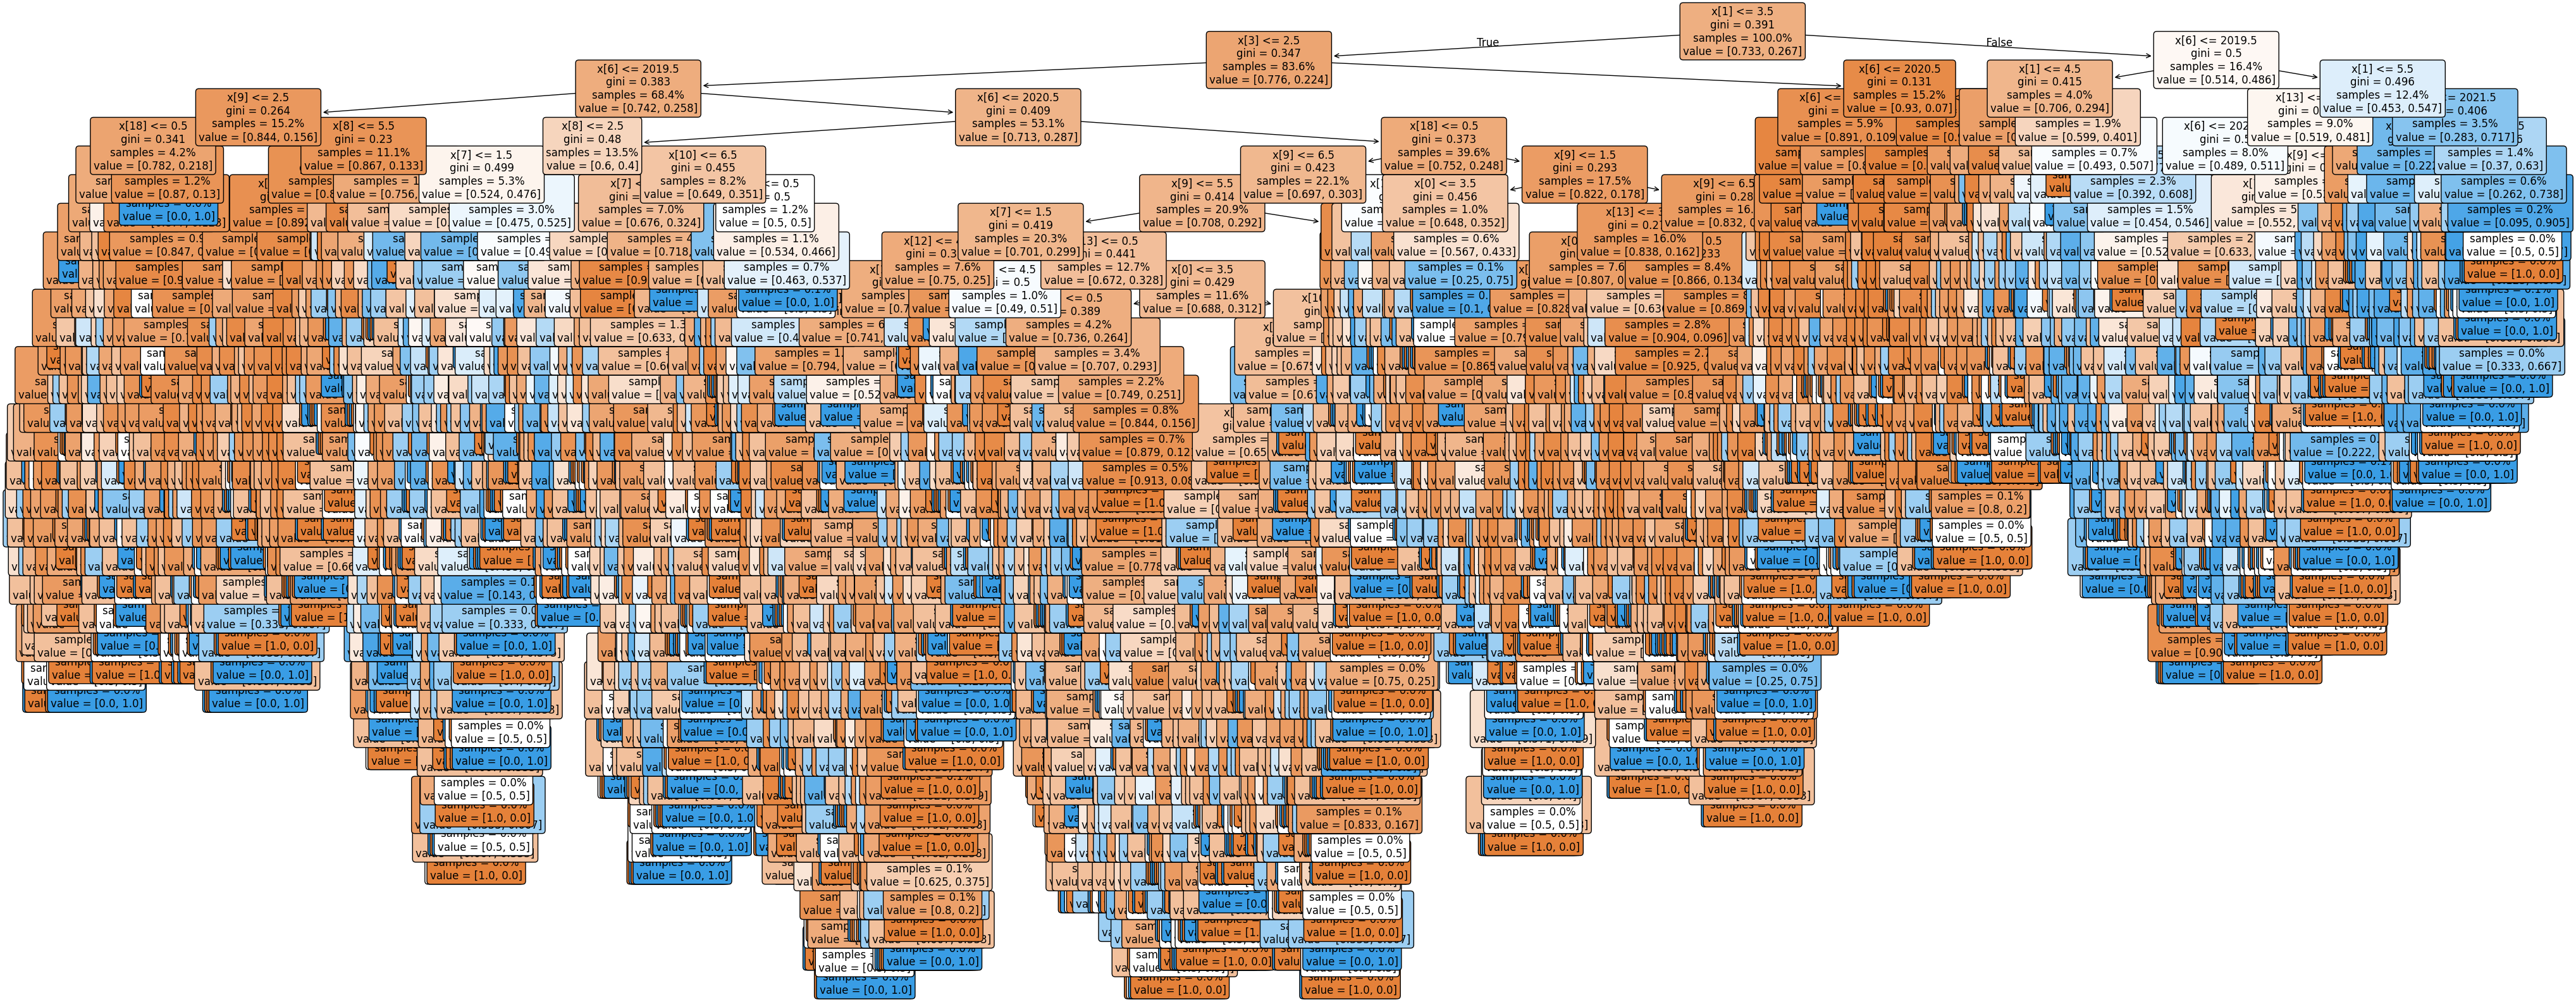

In [10]:
plt.figure(figsize=(50,20))
plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)
plt.show()

## 1.6 - Utilizando o algoritmo de Minimal Cost-Complexity

/var/folders/b3/tnw0w2412xq8w53y02gqbr240000gn/T/ipykernel_71541/306740880.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


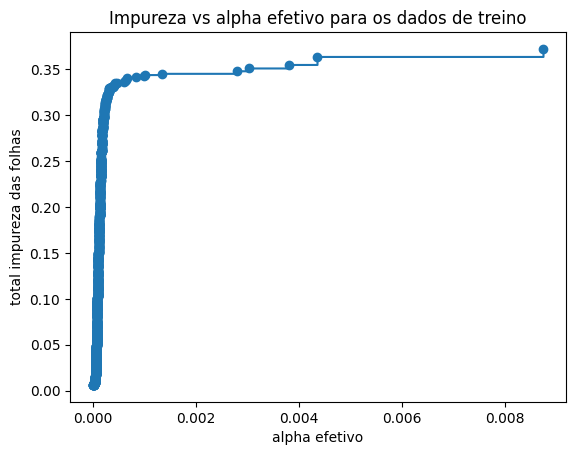

In [11]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 1.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [12]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))

param_grid = {
    'ccp_alpha': alphas_reduzidos,
    'class_weight':['balanced'],
    'max_depth': [3, 5, 10, 15],

}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=-1)

CV_clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eval: %0.4f' % (1 - accuracy_score(y_val, CV_clf.predict(X_val))))

print(classification_report(y_val, CV_clf.predict(X_val)))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV] END ..ccp_alpha=0.0, class_weight=balanced, max_depth=3; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=10; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=10; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=10; total time=   0.0s
[CV] END ..ccp_alpha=0.0, class_weight=balanced, max_depth=3; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=10; total time=   0.0s
[CV] END ..ccp_alpha=0.0, class_weight=balanced, max_depth=3; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=10; total time=   0.0s
[CV] END ..ccp_alpha=0.0, class_weight=balanced, max_depth=3; total time=   0.0s
[CV] END ..ccp_alpha=0.0, class_weight=balanced, max_depth=3; total time=   0.0s
[CV] END .ccp_alpha=0.0, class_weight=balanced, max_depth=15; total time=   0.0s
[CV] END ..ccp_alpha=0.0, class_weight=balanc

In [15]:
CV_clf.best_params_

{'ccp_alpha': 0.0006598310104643302,
 'class_weight': 'balanced',
 'max_depth': 10}

## Treinando o modelo com todos os dados

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = DecisionTreeClassifier(**CV_clf.best_params_)
clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, clf.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, clf.predict(X_test))))

print(classification_report(y_test, clf.predict(X_test)))

Ein: 0.3189
Eout: 0.3285
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      2190
           1       0.42      0.64      0.51       790

    accuracy                           0.67      2980
   macro avg       0.63      0.66      0.63      2980
weighted avg       0.73      0.67      0.69      2980



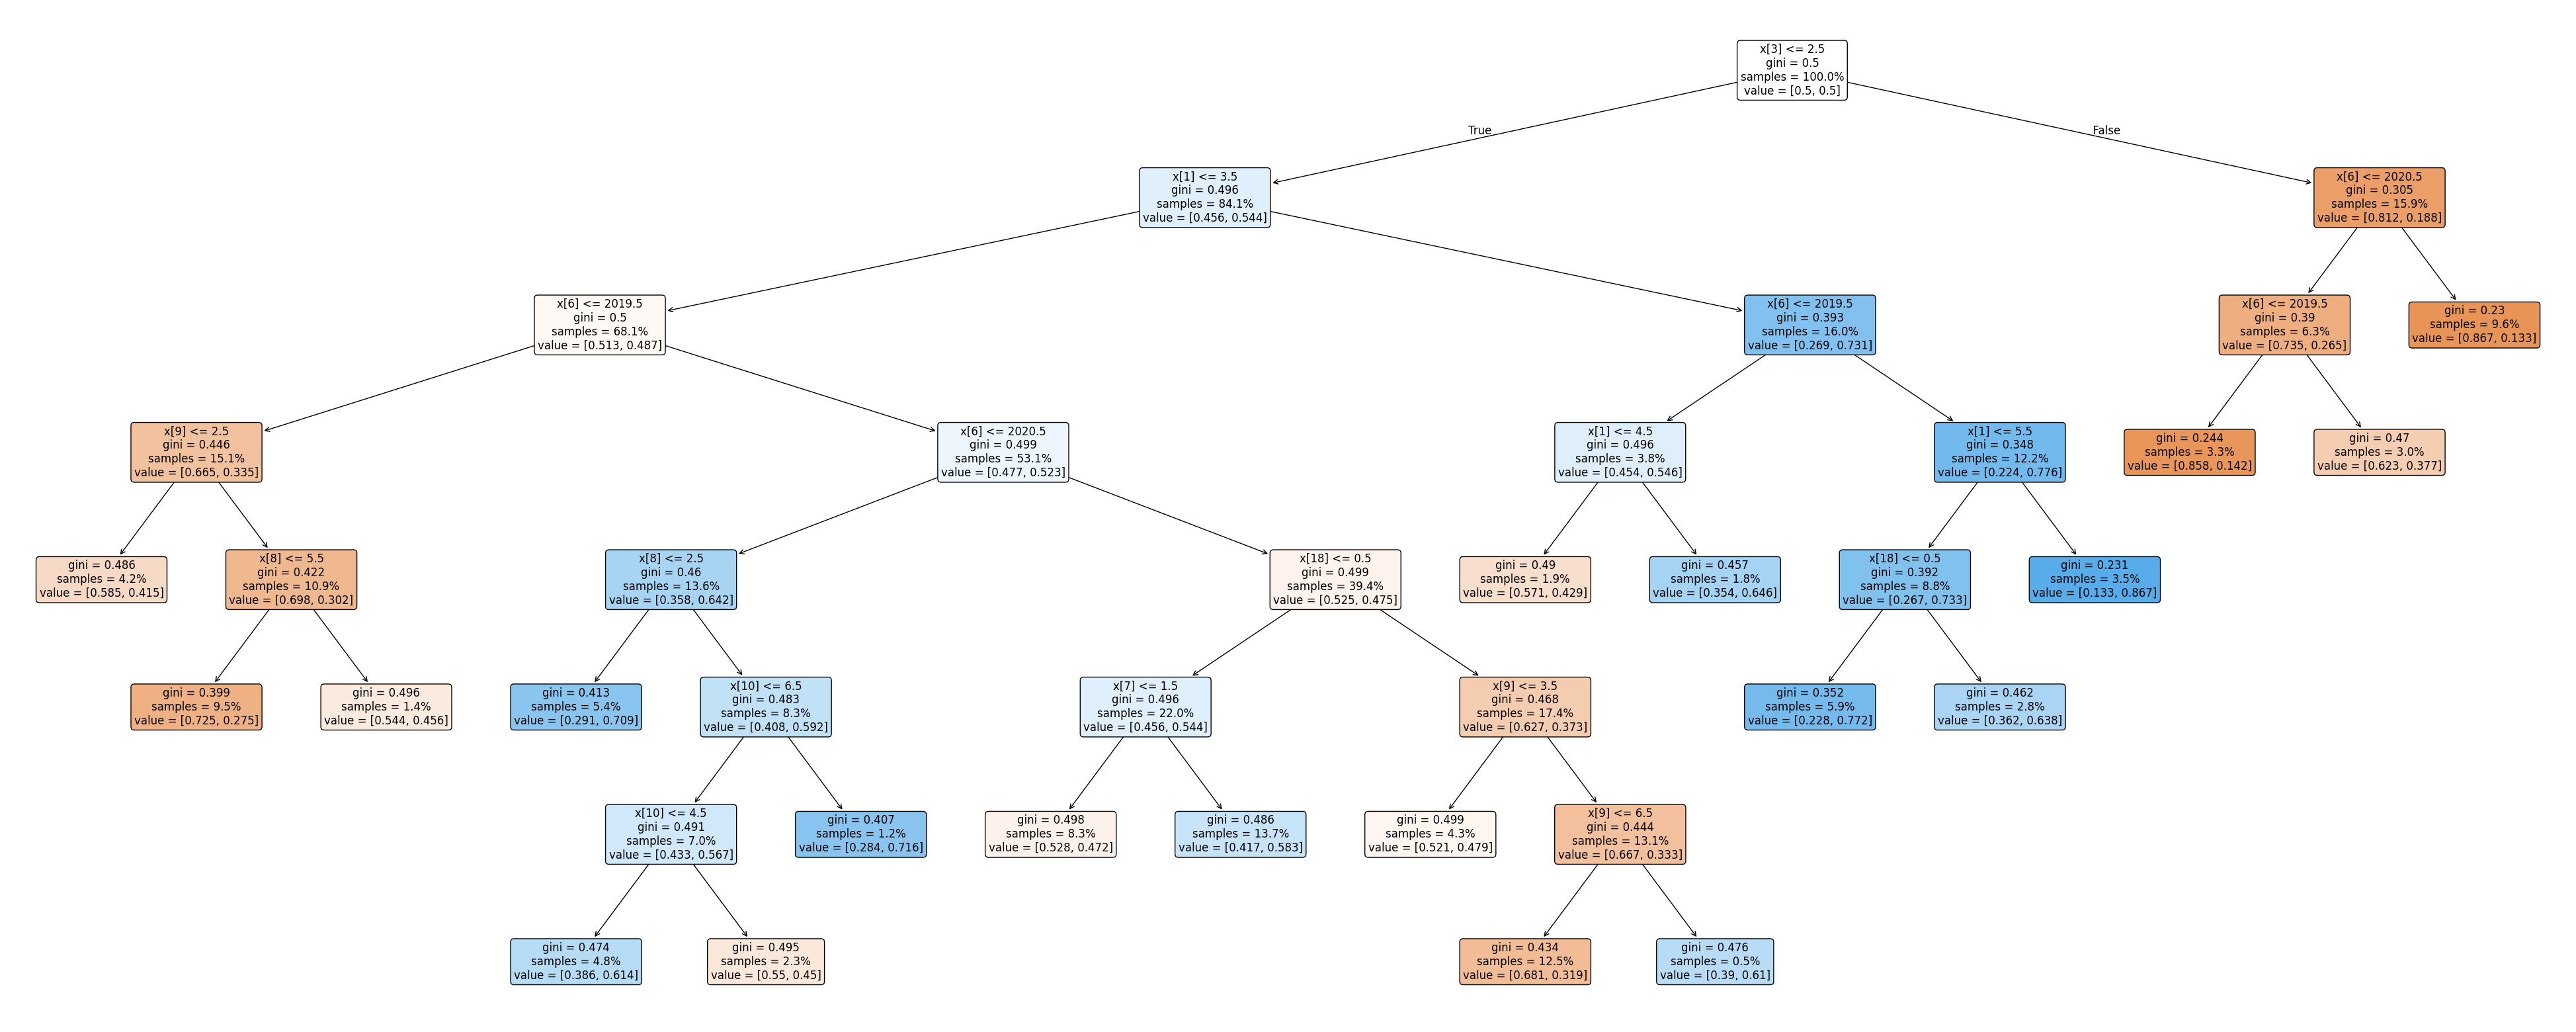

In [17]:
plt.figure(figsize=(50,20))

plot_tree(
    clf,
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
)

plt.show()